In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [2]:
trajectory = pd.read_csv('pedestrian_positions_20251124_064305.csv')

trajectory = trajectory[['x', 'y']]

trajectory.head()

# Drop first 3500 rows
trajectory_drop = trajectory.iloc[3500::10]
trajectory_drop.head()

,x,y
3500,-1.5,-3.0
3510,-1.5,-3.0
3520,-1.5,-3.0
3530,-1.5,-3.0
3540,-1.5,-3.0


In [3]:
trajectory_drop.describe()

,x,y
count,565.000000,565.000000
mean,-2.678942,-2.542754
std,1.863208,0.959648
min,-5.658000,-4.080000
25%,-4.666000,-3.698000
50%,-2.789000,-1.751000
75%,-0.564000,-1.708000
max,-0.564000,-1.216000


<Axes: xlabel='x', ylabel='y'>

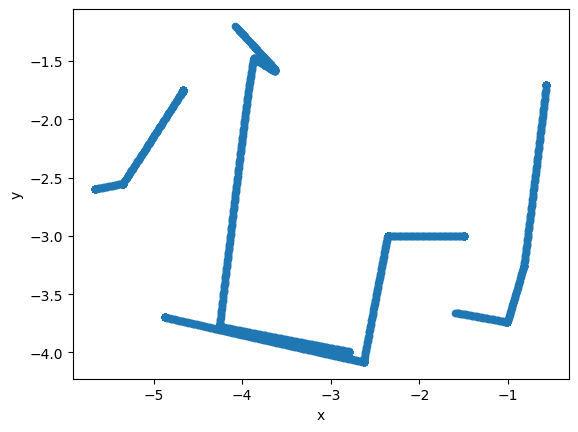

In [13]:
trajectory.plot.scatter(x='x', y='y')

<Axes: xlabel='x', ylabel='y'>

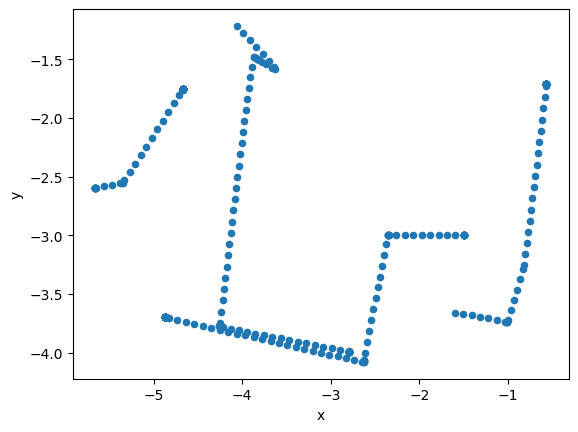

In [4]:
trajectory_drop.plot.scatter(x='x', y='y')

  Cluster 0: center at [-1.52123077 -3.        ]
  Cluster 1: center at [-2.33281818 -3.02254545]
  Cluster 2: center at [-2.77976471 -4.00492157]
  Cluster 3: center at [-4.229      -3.77753333]
  Cluster 4: center at [-4.871      -3.69901389]
  Cluster 5: center at [-5.63333333 -2.59341667]
  Cluster 6: center at [-4.66804762 -1.75344048]
  Cluster 7: center at [-3.78446667 -1.4996    ]
  Cluster 8: center at [-0.56429016 -1.70978756]


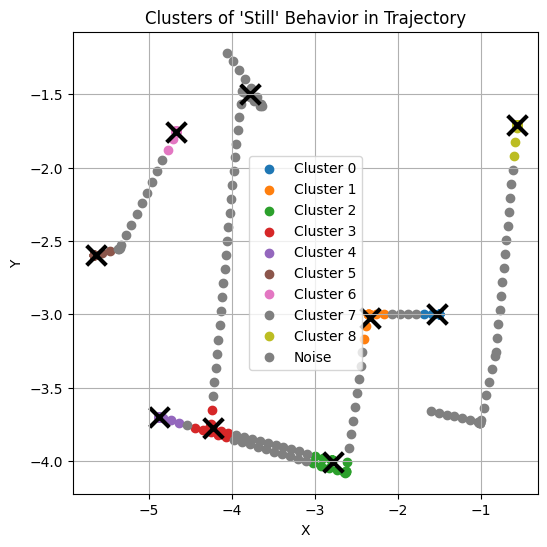

In [14]:
df = trajectory_drop[['x', 'y']].to_numpy()
db = DBSCAN(eps=0.15, min_samples=10).fit(df)

# df = trajectory[['x', 'y']].to_numpy()
# db = DBSCAN(eps=0.15, min_samples=100).fit(df)

labels = db.labels_

# -1 means noise (not in any cluster)
unique_clusters = set(labels) - {-1}
# print("Detected clusters:", unique_clusters)

# Compute cluster centers (where person stays the most)
cluster_centers = {}

for cluster_id in unique_clusters:
    points = df[labels == cluster_id]
    center = points.mean(axis=0)
    cluster_centers[cluster_id] = center

# print("\nCluster centers (likely 'still' locations):")
for cid, ctr in cluster_centers.items():
    print(f"  Cluster {cid}: center at {ctr}")

# ------------------------------------------
# Visualization
# ------------------------------------------
plt.figure(figsize=(6, 6))

# Plot each cluster
for cluster_id in unique_clusters:
    pts = df[labels == cluster_id]
    plt.scatter(pts[:,0], pts[:,1], label=f"Cluster {cluster_id}")

# Plot noise
noise = df[labels == -1]
if len(noise) > 0:
    plt.scatter(noise[:,0], noise[:,1], color='gray', label='Noise')

# Plot centers
for cid, ctr in cluster_centers.items():
    plt.scatter(ctr[0], ctr[1], marker='x', s=200, linewidths=3, color='black')

plt.legend()
plt.title("Clusters of 'Still' Behavior in Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [7]:
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import numpy as np

# # 1. Prepare the data
# # For demonstration, let's create some evolving data points
# x_data = df[:, 0]
# y_data = df[:, 1]

# # 2. Set up the figure and axes
# fig, ax = plt.subplots()
# # Create an initial plot object (e.g., a scatter plot)
# # The comma after 'line' is important to unpack the single-element tuple returned by plot
# line, = ax.plot([], [], 'o-')

# # Optionally set axis limits
# # ax.set_xlim(0, 1)
# # ax.set_ylim(0, 1)

# # 3. Define the animation function
# # This function will be called repeatedly by FuncAnimation
# def animate(i, x_data, y_data):
#     # print("i = ", i)
#     line.set_data(x_data[:i+1], y_data[:i+1])
#     return line, # Return the updated plot element(s)

# # 4. Create the animation
# # fig: The figure to animate
# # animate: The function to call each frame
# # interval: Delay between frames in milliseconds
# # blit: Whether to use blitting for performance (True for faster updates)
# ani = animation.FuncAnimation(
#     fig, 
#     animate, 
#     frames=len(x_data),
#     interval=100, 
#     blit=True, 
#     fargs=(x_data, y_data)
# )

# # 5. Display the animation
# from IPython.display import HTML
# HTML(ani.to_jshtml())
# # plt.show()